In [104]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import duckdb
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

In [105]:
sales = pd.read_csv("../data/sales_train_evaluation.csv")
calendar = pd.read_csv("../data/calendar.csv")
sell_prices = pd.read_csv("../data/sell_prices.csv")
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [106]:
sell_prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [107]:
#Reshape Data:

sales_long = sales.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    var_name="d",
    value_name="demand"
)

In [108]:
sell_prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [109]:
# Merge with Calendar
sales_long = sales_long.merge(
    calendar[["d", "date", "wm_yr_wk"]],
    on="d",
    how="left"
)

In [110]:
#For Volume/Demand Analysis

In [111]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101


In [112]:
# For Price & Revenue Analysis

In [113]:
sales_long_with_price = sales_long.merge(
    sell_prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

In [114]:
sales_priced = sales_long_with_price.dropna(subset=["sell_price"]).copy()
sales_priced["revenue"] = sales_priced["demand"] * sales_priced["sell_price"]

In [115]:
sales_priced.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,sell_price,revenue
7,HOBBIES_1_008_CA_1_evaluation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_1,12,2011-01-29,11101,0.46,5.52
8,HOBBIES_1_009_CA_1_evaluation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,d_1,2,2011-01-29,11101,1.56,3.12
9,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,3.17,0.00
11,HOBBIES_1_012_CA_1_evaluation,HOBBIES_1_012,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,5.98,0.00
14,HOBBIES_1_015_CA_1_evaluation,HOBBIES_1_015,HOBBIES_1,HOBBIES,CA_1,CA,d_1,4,2011-01-29,11101,0.70,2.80


In [116]:
sales_long["date"] = pd.to_datetime(sales_long["date"])
sales_priced["date"] = pd.to_datetime(sales_priced["date"])

In [117]:
# Fast Moving Items: Adds all demand across time and stores for each item

item_demand = duckdb.query("""
                          
SELECT item_id, SUM(demand) AS total_demand
FROM sales_long
GROUP BY item_id
ORDER BY total_demand DESC
                                                  
""").to_df()

In [118]:
item_demand.head()

,item_id,total_demand
0,FOODS_3_090,1017916.0
1,FOODS_3_586,932236.0
2,FOODS_3_252,573723.0
3,FOODS_3_555,497881.0
4,FOODS_3_587,402159.0


In [119]:
# Sales by Store - Store Performance Chart

store_demand = duckdb.query("""

SELECT store_id, SUM(demand) AS total_demand
FROM sales_long
GROUP BY store_id
ORDER BY total_demand DESC                           

""").to_df()

In [120]:
store_demand.head()


,store_id,total_demand
0,CA_3,11363540.0
1,CA_1,7832248.0
2,TX_2,7329642.0
3,WI_2,6697988.0
4,WI_3,6542557.0


In [121]:
#Sales by State:
state_demand = duckdb.query("""
                           
SELECT state_id, SUM(demand) AS total_demand
FROM sales_long
GROUP BY state_id
ORDER BY total_demand DESC

""").to_df()

In [122]:
state_map = {
    "CA": "California",
    "TX": "Texas",
    "WI": "Wisconsin"
}

state_demand["state_name"] = state_demand["state_id"].map(state_map)
state_demand.head()

,state_id,total_demand,state_name
0,CA,29196717.0,California
1,TX,19228405.0,Texas
2,WI,18502051.0,Wisconsin


In [123]:
# Item Movement - Fast Moving, Slow Moving Analysis

item_movement = duckdb.query("""
    WITH ranked_items AS (
        SELECT
            item_id,
            SUM(demand) AS total_demand,
            ROW_NUMBER() OVER (ORDER BY SUM(demand) DESC) AS demand_rank,
            COUNT(*) OVER () AS total_items
        FROM sales_long
        GROUP BY item_id
    )
    SELECT
        item_id,
        total_demand,
        demand_rank,
        CAST(demand_rank AS DOUBLE) / total_items AS percentile_rank,
        CASE
            WHEN CAST(demand_rank AS DOUBLE) / total_items <= 0.2 THEN 'Fast-moving'
            WHEN CAST(demand_rank AS DOUBLE) / total_items <= 0.8 THEN 'Medium'
            ELSE 'Slow-moving'
        END AS movement_type
    FROM ranked_items
    ORDER BY total_demand DESC
""").to_df()

In [124]:
item_movement.tail()

,item_id,total_demand,demand_rank,percentile_rank,movement_type
3044,HOBBIES_2_084,786.0,3045,0.998688,Slow-moving
3045,HOUSEHOLD_2_005,782.0,3046,0.999016,Slow-moving
3046,HOUSEHOLD_2_175,759.0,3047,0.999344,Slow-moving
3047,HOBBIES_2_119,673.0,3048,0.999672,Slow-moving
3048,HOUSEHOLD_2_101,593.0,3049,1.000000,Slow-moving


In [125]:
# Daily Revenue: 

daily_revenue = duckdb.query("""
SELECT date, SUM(revenue) AS total_revenue
FROM sales_priced
GROUP BY date
ORDER BY date
""").to_df()

In [126]:
daily_revenue.head()

,date,total_revenue
0,2011-01-29,81650.61
1,2011-01-30,78970.57
2,2011-01-31,57706.91
3,2011-02-01,60761.20
4,2011-02-02,46959.95


In [127]:
# Revenue by State:

state_revenue = duckdb.query("""
    SELECT state_id,SUM(revenue) AS total_revenue
    FROM sales_priced
    GROUP BY state_id
    ORDER BY total_revenue DESC
""").to_df()

state_revenue["state_name"] = state_revenue["state_id"].map(state_map)

In [128]:
state_revenue.head()

,state_id,total_revenue,state_name
0,CA,8.596736e+07,California
1,TX,5.512064e+07,Texas
2,WI,5.048954e+07,Wisconsin


In [129]:
# Item Revenue

item_revenue = duckdb.query("""
SELECT item_id, SUM (revenue) AS total_revenue
FROM sales_priced
GROUP BY item_id
ORDER BY total_revenue DESC
""").to_df()

In [130]:
item_revenue.head()

,item_id,total_revenue
0,FOODS_3_586,1482295.48
1,FOODS_3_120,1444850.10
2,FOODS_3_090,1377664.04
3,FOODS_3_202,1272487.14
4,FOODS_3_587,991308.02


In [131]:
#Item Summary

item_summary = duckdb.query("""
SELECT 
    item_id,
    SUM(demand) AS total_demand,
    SUM(revenue) AS total_revenue,
    AVG(sell_price) AS avg_price
FROM sales_priced
GROUP BY item_id
ORDER BY total_revenue DESC
""").to_df()

In [132]:
item_summary = item_summary.merge(
    item_movement[["item_id","movement_type"]],
    on="item_id",
    how="left"
)

In [133]:
item_summary.head()

,item_id,total_demand,total_revenue,avg_price,movement_type
0,FOODS_3_586,932236.0,1482295.48,1.594493,Fast-moving
1,FOODS_3_120,290132.0,1444850.10,4.978097,Fast-moving
2,FOODS_3_090,1017916.0,1377664.04,1.361844,Fast-moving
3,FOODS_3_202,300529.0,1272487.14,4.256523,Fast-moving
4,FOODS_3_587,402159.0,991308.02,2.516136,Fast-moving


In [134]:
# For KPI
## Total Revenue:

total_revenue_df = duckdb.query("""
SELECT SUM(revenue) AS value
FROM sales_priced
""").to_df()

In [135]:
## Avg Price:

avg_price_df = duckdb.query("""
SELECT AVG(sell_price) AS value
FROM sales_priced
""").to_df()

In [136]:
## Top Item:

top_item_df = duckdb.query("""
SELECT item_id AS value
FROM (
    SELECT item_id, SUM(revenue) AS total_revenue
    FROM sales_priced
    GROUP BY item_id
    ORDER BY total_revenue DESC
    LIMIT 1                                          
    )
""").to_df()

In [137]:
top_item_df

,value
0,FOODS_3_586


In [138]:
top_state_df = duckdb.query("""
    SELECT state_id AS value
    FROM (
        SELECT
            state_id,
            SUM(revenue) AS total_revenue
        FROM sales_priced
        GROUP BY state_id
        ORDER BY total_revenue DESC
        LIMIT 1
    )
""").to_df()

In [139]:
top_state_df

,value
0,CA


In [140]:
kpi_table = pd.DataFrame({
    "Metric": ["Total Revenue", "Avg Price", "Top Item", "Top State"],
    "Value": [
        total_revenue_df.loc[0, "value"],
        avg_price_df.loc[0, "value"],
        top_item_df.loc[0, "value"],
        top_state_df.loc[0, "value"]
    ]
})


In [141]:
kpi_table

,Metric,Value
0,Total Revenue,191577546.041236
1,Avg Price,4.409438
2,Top Item,FOODS_3_586
3,Top State,CA


In [145]:
monthly_demand = duckdb.query("""
    SELECT
        DATE_TRUNC('month', date) AS month,
        SUM(demand) AS total_demand
    FROM sales_long
    GROUP BY month
    ORDER BY month
""").to_df()

monthly_demand.head()

,month,total_demand
0,2011-01-01,88163.0
1,2011-02-01,726375.0
2,2011-03-01,763567.0
3,2011-04-01,737713.0
4,2011-05-01,719562.0


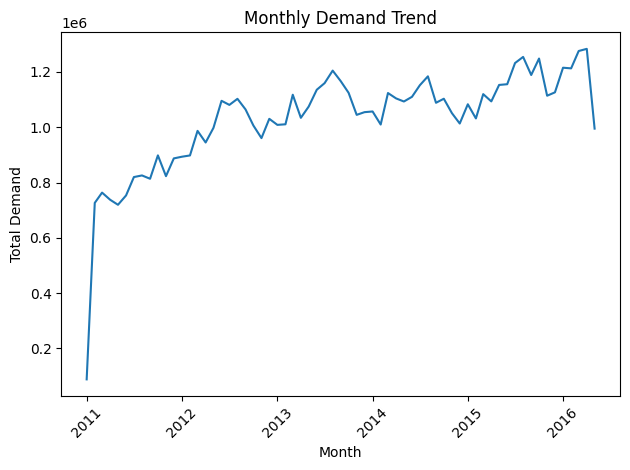

In [148]:
plt.figure()
plt.plot(monthly_demand["month"], monthly_demand["total_demand"])
plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

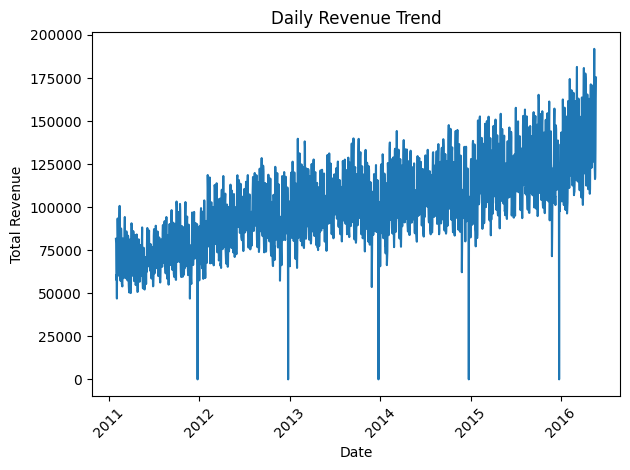

In [149]:
plt.figure()
plt.plot(daily_revenue["date"], daily_revenue["total_revenue"])
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [153]:
 item_revenue.head(10)

,item_id,total_revenue
0,FOODS_3_586,1482295.48
1,FOODS_3_120,1444850.10
2,FOODS_3_090,1377664.04
3,FOODS_3_202,1272487.14
4,FOODS_3_587,991308.02
5,FOODS_3_252,871806.24
6,FOODS_3_555,789009.48
7,FOODS_3_444,719129.24
8,HOBBIES_1_354,711937.14
9,FOODS_1_096,670077.06


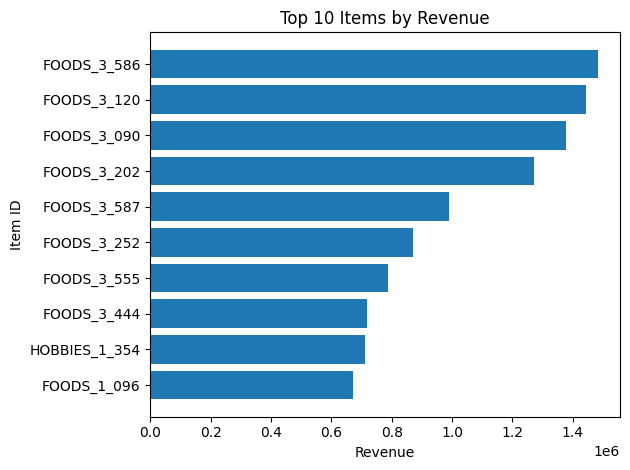

In [151]:
top10_items = item_revenue.head(10)

plt.figure()
plt.barh(top10_items["item_id"], top10_items["total_revenue"])
plt.title("Top 10 Items by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Item ID")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

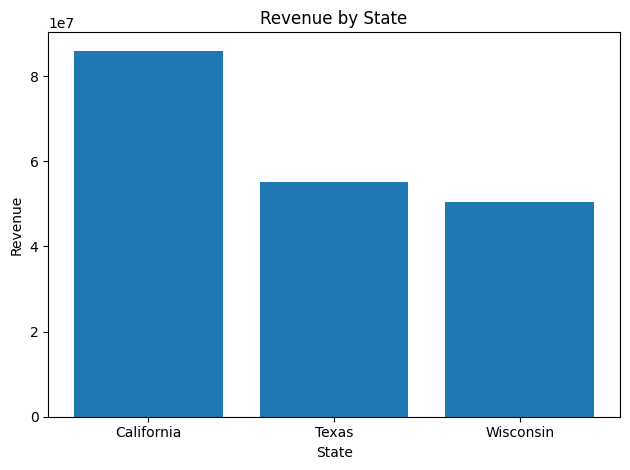

In [154]:
plt.figure()
plt.bar(state_revenue["state_name"], state_revenue["total_revenue"])
plt.title("Revenue by State")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

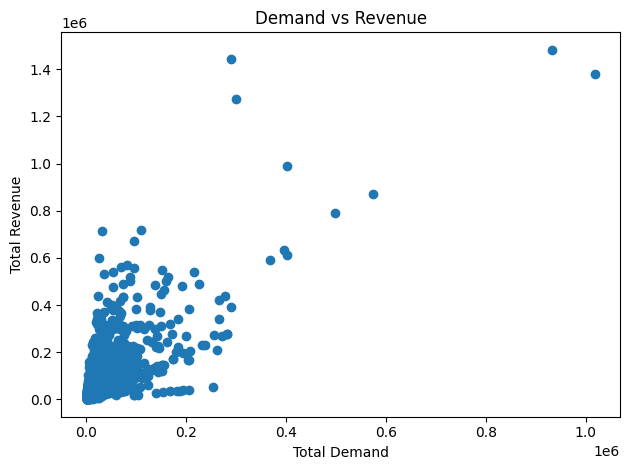

In [156]:
plt.figure()
plt.scatter(
    item_summary["total_demand"],
    item_summary["total_revenue"]
)

plt.title("Demand vs Revenue")
plt.xlabel("Total Demand")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

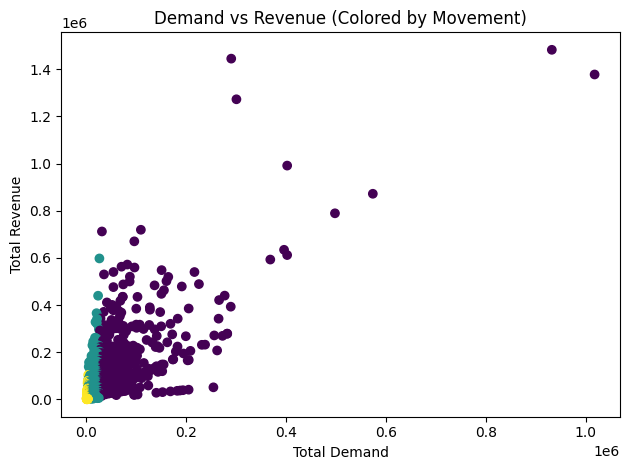

In [159]:
colors = {
    "Fast-moving": 0,
    "Medium": 1,
    "Slow-moving": 2
}

plt.figure()
plt.scatter(
    item_summary["total_demand"],
    item_summary["total_revenue"],
    c=item_summary["movement_type"].map(colors)
)

plt.title("Demand vs Revenue (Colored by Movement)")
plt.xlabel("Total Demand")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

,date,total_revenue
0,2011-01-29,81650.61
1,2011-01-30,78970.57
2,2011-01-31,57706.91
3,2011-02-01,60761.20
4,2011-02-02,46959.95


In [162]:
## Creating csv files for Tableau:
# 1: KPI Table
kpi_table.to_csv("../data_for_tableau/kpi_table.csv", index=False)

In [163]:
#2: Daily Demand Trend
daily_demand.to_csv("../data_for_tableau/daily_demand.csv", index=False)

In [164]:
#3: Daily Revenue Trend
daily_revenue.to_csv("../data_for_tableau/daily_revenue.csv", index=False)

In [165]:
#4: State Revenue
state_revenue.to_csv("../data_for_tableau/state_revenue.csv", index=False)


In [166]:
#5: Top Items (Revenue)
item_revenue.to_csv("../data_for_tableau/item_revenue.csv", index=False)

In [168]:
#6: item summary
item_summary.to_csv("../data_for_tableau/item_summary.csv", index=False)

In [169]:
#7: Item Movement
item_movement.to_csv("../data_for_tableau/item_movement.csv", index=False)

In [170]:
#8: Store Performance:
store_demand.to_csv("../data_for_tableau/store_demand.csv", index=False)